In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
import pandas as pd

df = pd.read_excel("customer_data.xlsx")

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'customer_data.xlsx'

In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Customer_segmentation.ipynb', 'dataset', 'notebook']


In [4]:
import pandas as pd

df = pd.read_excel("dataset/Customer_data.xlsx")

print(df.head())

PermissionError: [Errno 13] Permission denied: 'dataset/Customer_data.xlsx'

In [5]:
import os

print(os.listdir("dataset"))

['.ipynb_checkpoints', 'customer_data.xlsx']


In [6]:
import pandas as pd

df = pd.read_excel("dataset/customer_data.xlsx")

print(df.head())

PermissionError: [Errno 13] Permission denied: 'dataset/customer_data.xlsx'

In [7]:
import os

print(os.path.abspath("dataset/customer_data.xlsx"))

C:\Users\ADMIN\OneDrive\Desktop\Customer Segmentation Project\dataset\customer_data.xlsx


In [8]:
import os

print(os.path.isfile(r"dataset\customer_data.xlsx"))

True


In [9]:
import pandas as pd

df = pd.read_excel(
    r"dataset\customer_data.xlsx",
    engine="openpyxl"
)

print(df.head())

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [10]:
import pandas as pd

df = pd.read_excel("dataset/customer_data.xlsx")

print(df.head())

   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


In [11]:
print("Rows and Columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Rows and Columns: (200, 7)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (k$)', 'Spending Score (1-100)'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB
None


In [12]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Duplicate Rows: 0


In [13]:
df.columns = df.columns.str.strip()

In [14]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Education', 'Marital Status',
       'Annual Income (k$)', 'Spending Score (1-100)'],
      dtype='object')


In [15]:
print(df['Gender'].unique())

print(df['Education'].unique())

print(df['Marital Status'].unique())

['M' 'F']
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
['Married' 'Single' 'Unknown' 'Divorced']


In [16]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_education = LabelEncoder()
le_marital = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Education'] = le_education.fit_transform(df['Education'])
df['Marital Status'] = le_marital.fit_transform(df['Marital Status'])

print(df.head())

   CustomerID  Gender  Age  Education  Marital Status  Annual Income (k$)  \
0           1       1   19          3               1                  15   
1           2       1   21          2               2                  15   
2           3       0   20          2               1                  16   
3           4       0   23          3               3                  16   
4           5       0   31          5               1                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


In [17]:
X = df[['Age',
        'Gender',
        'Education',
        'Marital Status',
        'Annual Income (k$)',
        'Spending Score (1-100)']]

print(X.head())

   Age  Gender  Education  Marital Status  Annual Income (k$)  \
0   19       1          3               1                  15   
1   21       1          2               2                  15   
2   20       0          2               1                  16   
3   23       0          3               3                  16   
4   31       0          5               1                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879  1.12815215 -0.02254317 -0.55366729 -1.73899919 -0.43480148]
 [-1.28103541  1.12815215 -0.58612249  0.84802206 -1.73899919  1.19570407]
 [-1.3528021  -0.88640526 -0.58612249 -0.55366729 -1.70082976 -1.71591298]
 [-1.13750203 -0.88640526 -0.02254317  2.24971141 -1.70082976  1.04041783]
 [-0.56336851 -0.88640526  1.10461547 -0.55366729 -1.66266033 -0.39597992]]


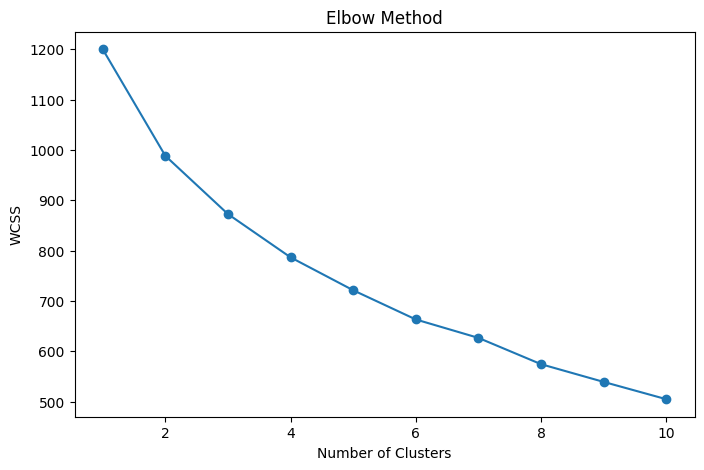

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [20]:
print(wcss)

[1200.0000000000002, 988.1942964646034, 872.4494483586654, 786.4770408758702, 721.1028939553468, 663.0654070344348, 626.4466537531033, 574.1950354011761, 538.9874821420568, 504.6305756309194]


In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df[['CustomerID', 'Cluster']].head())

   CustomerID  Cluster
0           1        1
1           2        1
2           3        3
3           4        3
4           5        3


In [22]:
print(df['Cluster'].value_counts())
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

Cluster
2    54
0    46
3    45
4    28
1    27
Name: count, dtype: int64
         CustomerID    Gender        Age  Education  Marital Status  \
Cluster                                                               
0        103.500000  1.000000  50.021739   3.282609        1.391304   
1         68.629630  1.000000  26.629630   3.814815        1.629630   
2         99.518519  0.000000  48.648148   2.944444        1.388889   
3         73.577778  0.000000  27.133333   2.511111        1.555556   
4        171.464286  0.535714  32.214286   2.928571        0.928571   

         Annual Income (k$)  Spending Score (1-100)  
Cluster                                              
0                 60.978261               29.043478  
1                 46.370370               65.222222  
2                 60.925926               36.037037  
3                 48.088889               60.733333  
4                 92.892857               80.857143  
